# AMI Audit on the Full PPG Dataset

This notebook implements the complete design in `STEP3_AMI_AUDIT.md`.
The primary analysis estimates one delay per NTSA-ready window with KSG-1
and the first strict local minimum of the AMI curve.

Primary configuration:

- `k = 3`;
- `max_lag = 1.0 s`, converted to samples using each session's `fs`;
- stationarity filtering is applied separately to Raw and Processed PPG;
- a missing first local minimum remains `tau = None`.

In [1]:
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


def find_project_root():
    "Return the repository root."
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "phase1" / "src").is_dir():
            return candidate
    raise FileNotFoundError("Cannot locate the repository root.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "phase1" / "src"
DATA_DIR = PROJECT_ROOT / "phase1" / "segmentated_data" / "dhdata"
OUTPUT_DIR = PROJECT_ROOT / "phase1" / "results" / "ami"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataloader.loader import get_data
from embedding.ami import auto_mutual_information

WINDOW_SIZES = (60, 120, 180)
STATES = {0: "Awake", 1: "Drowsy"}
REPRESENTATIONS = ("raw", "processed")
K_MAIN = 3
MAX_LAG_SECONDS = 1.0
K_VALUES = (2, 3, 4)
MAX_LAG_SENSITIVITY = (0.5, 1.0, 1.5)
JITTER = 0.0
RANDOM_STATE = 42
FORCE_RECOMPUTE = False

INDEX_PATH = DATA_DIR / "segments_index.csv"
WINDOW_RESULTS_PATH = OUTPUT_DIR / "ami_window_results.csv"
SESSION_SUMMARY_PATH = OUTPUT_DIR / "ami_session_summary.csv"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Shared analysis functions

The helpers below keep the physical lag range constant across sampling rates,
preserve `tau=None`, and retain all required window-level identifiers.

In [2]:
def natural_key(value):
    "Return a natural-sort key."
    parts = re.split(r"(\d+)", str(value))
    return [int(part) if part.isdigit() else part.lower() for part in parts]


def lag_in_samples(max_lag_seconds, fs, n_samples):
    "Convert a physical lag range to samples."
    max_lag = int(round(max_lag_seconds * fs))
    return min(max(max_lag, 2), n_samples - 1)


def estimate_window(signal, fs, k, max_lag_seconds):
    "Estimate AMI and the first local minimum for one window."
    max_lag = lag_in_samples(max_lag_seconds, fs, len(signal))
    tau, lags, ami = auto_mutual_information(
        signal,
        max_lag=max_lag,
        k=k,
        jitter=JITTER,
        random_state=RANDOM_STATE,
    )
    tau_seconds = np.nan if tau is None else tau / fs
    ami_at_tau = np.nan if tau is None else ami[tau - 1]
    return {
        "tau_samples": np.nan if tau is None else tau,
        "tau_seconds": tau_seconds,
        "ami_at_tau": ami_at_tau,
        "tau_found": tau is not None,
        "max_lag_samples": max_lag,
        "lags": lags,
        "ami": ami,
    }


def iter_session_windows(session, window_sizes=WINDOW_SIZES):
    "Yield stationary windows for both representations."
    for representation in REPRESENTATIONS:
        awake, drowsy = get_data(
            session,
            data_dir=DATA_DIR,
            window_sizes=window_sizes,
            stationarity=representation,
        )
        state_batches = {"Awake": awake, "Drowsy": drowsy}

        for label, state_data in state_batches.items():
            for window_size in window_sizes:
                batch = state_data[window_size]
                signals = batch[representation]
                for index, signal in enumerate(signals):
                    yield {
                        "session": session,
                        "window_id": int(batch["window_id"][index]),
                        "window_size_s": window_size,
                        "label": label,
                        "representation": representation.title(),
                        "fs": float(batch["fs"]),
                        "signal": signal,
                    }


def run_ami_rows(rows, k=K_MAIN, max_lag_seconds=MAX_LAG_SECONDS):
    "Run AMI for an iterable of window dictionaries."
    records = []
    curves = []
    for row in rows:
        result = estimate_window(
            row["signal"],
            row["fs"],
            k=k,
            max_lag_seconds=max_lag_seconds,
        )
        record = {key: value for key, value in row.items() if key != "signal"}
        record.update({
            key: result[key]
            for key in (
                "tau_samples",
                "tau_seconds",
                "ami_at_tau",
                "tau_found",
                "max_lag_samples",
            )
        })
        records.append(record)
        curves.append({**record, "lags": result["lags"], "ami": result["ami"]})
    return pd.DataFrame(records), curves


def summarize_group(group):
    "Summarize tau within one analysis group."
    tau = group["tau_seconds"].dropna()
    q1 = tau.quantile(0.25) if len(tau) else np.nan
    q3 = tau.quantile(0.75) if len(tau) else np.nan
    return pd.Series({
        "n_windows": len(group),
        "n_tau_found": int(group["tau_found"].sum()),
        "median_tau_seconds": tau.median(),
        "iqr_tau_seconds": q3 - q1,
        "tau_found_rate": 100.0 * group["tau_found"].mean(),
    })

## Dataset inventory

The exported index defines the analysis cohort. Raw and Processed counts are
calculated with their own stationarity flags.

In [3]:
index = pd.read_csv(INDEX_PATH)
sessions = sorted(index["session"].unique(), key=natural_key)

inventory_rows = []
for window_size in WINDOW_SIZES:
    subset = index[index["window_size_s"] == window_size]
    for label_code, label in STATES.items():
        state_rows = subset[subset["label"] == label_code]
        inventory_rows.append({
            "window_size_s": window_size,
            "label": label,
            "n_exported": len(state_rows),
            "n_stationary_raw": int(
                state_rows["stationarity_pass_raw"].sum()
            ),
            "n_stationary_processed": int(
                state_rows["stationarity_pass_processed"].sum()
            ),
        })

inventory = pd.DataFrame(inventory_rows)
display(inventory)
print(f"Sessions: {len(sessions)}")
expected_raw = int(index["stationarity_pass_raw"].sum())
expected_processed = int(index["stationarity_pass_processed"].sum())
print(
    "Expected window-representation records: "
    f"{expected_raw + expected_processed}"
)

,window_size_s,label,n_exported,n_stationary_raw,n_stationary_processed
0,60,Awake,623,550,596
1,60,Drowsy,328,267,305
2,120,Awake,284,245,269
3,120,Drowsy,148,118,136
4,180,Awake,168,147,161
5,180,Drowsy,86,71,77


Sessions: 20
Expected window-representation records: 2942


## 1. Sanity check on one complete session

The notebook automatically selects the first naturally sorted session with at
least one stationary Awake and Drowsy window in every size and representation.
Every eligible window in that session is evaluated.

In [4]:
def session_is_complete(session):
    "Check coverage of every required group."
    for representation in REPRESENTATIONS:
        awake, drowsy = get_data(
            session,
            data_dir=DATA_DIR,
            stationarity=representation,
        )
        for state_data in (awake, drowsy):
            for window_size in WINDOW_SIZES:
                if len(state_data[window_size][representation]) == 0:
                    return False
    return True


sanity_session = next(
    session for session in sessions if session_is_complete(session)
)
sanity_results, sanity_curves = run_ami_rows(
    iter_session_windows(sanity_session)
)

assert not sanity_results.empty
assert np.isfinite(sanity_results["ami_at_tau"].dropna()).all()
assert (
    sanity_results.loc[
        sanity_results["tau_found"], "tau_samples"
    ] <= sanity_results.loc[
        sanity_results["tau_found"], "max_lag_samples"
    ]
).all()
assert np.allclose(
    sanity_results.loc[
        sanity_results["tau_found"], "tau_seconds"
    ],
    sanity_results.loc[
        sanity_results["tau_found"], "tau_samples"
    ] / sanity_results.loc[sanity_results["tau_found"], "fs"],
)

for curve in sanity_curves:
    assert np.isfinite(curve["ami"]).all()
    assert len(curve["ami"]) == curve["max_lag_samples"]

sanity_summary = (
    sanity_results
    .groupby(
        ["window_size_s", "label", "representation"],
        observed=True,
    )
    .agg(
        n_windows=("window_id", "size"),
        n_tau_found=("tau_found", "sum"),
        min_tau_samples=("tau_samples", "min"),
        max_tau_samples=("tau_samples", "max"),
    )
    .reset_index()
)

print(f"Sanity session: {sanity_session}")
display(sanity_summary)

Sanity session: sample_4.csv


,window_size_s,label,representation,n_windows,n_tau_found,min_tau_samples,max_tau_samples
0,60,Awake,Processed,29,29,3,9
1,60,Awake,Raw,29,29,4,11
2,60,Drowsy,Processed,17,17,3,8
3,60,Drowsy,Raw,17,17,4,11
4,120,Awake,Processed,13,13,3,9
5,120,Awake,Raw,13,13,4,14
6,120,Drowsy,Processed,7,7,3,8
7,120,Drowsy,Raw,7,7,4,10
8,180,Awake,Processed,8,8,3,8
9,180,Awake,Raw,8,8,4,12


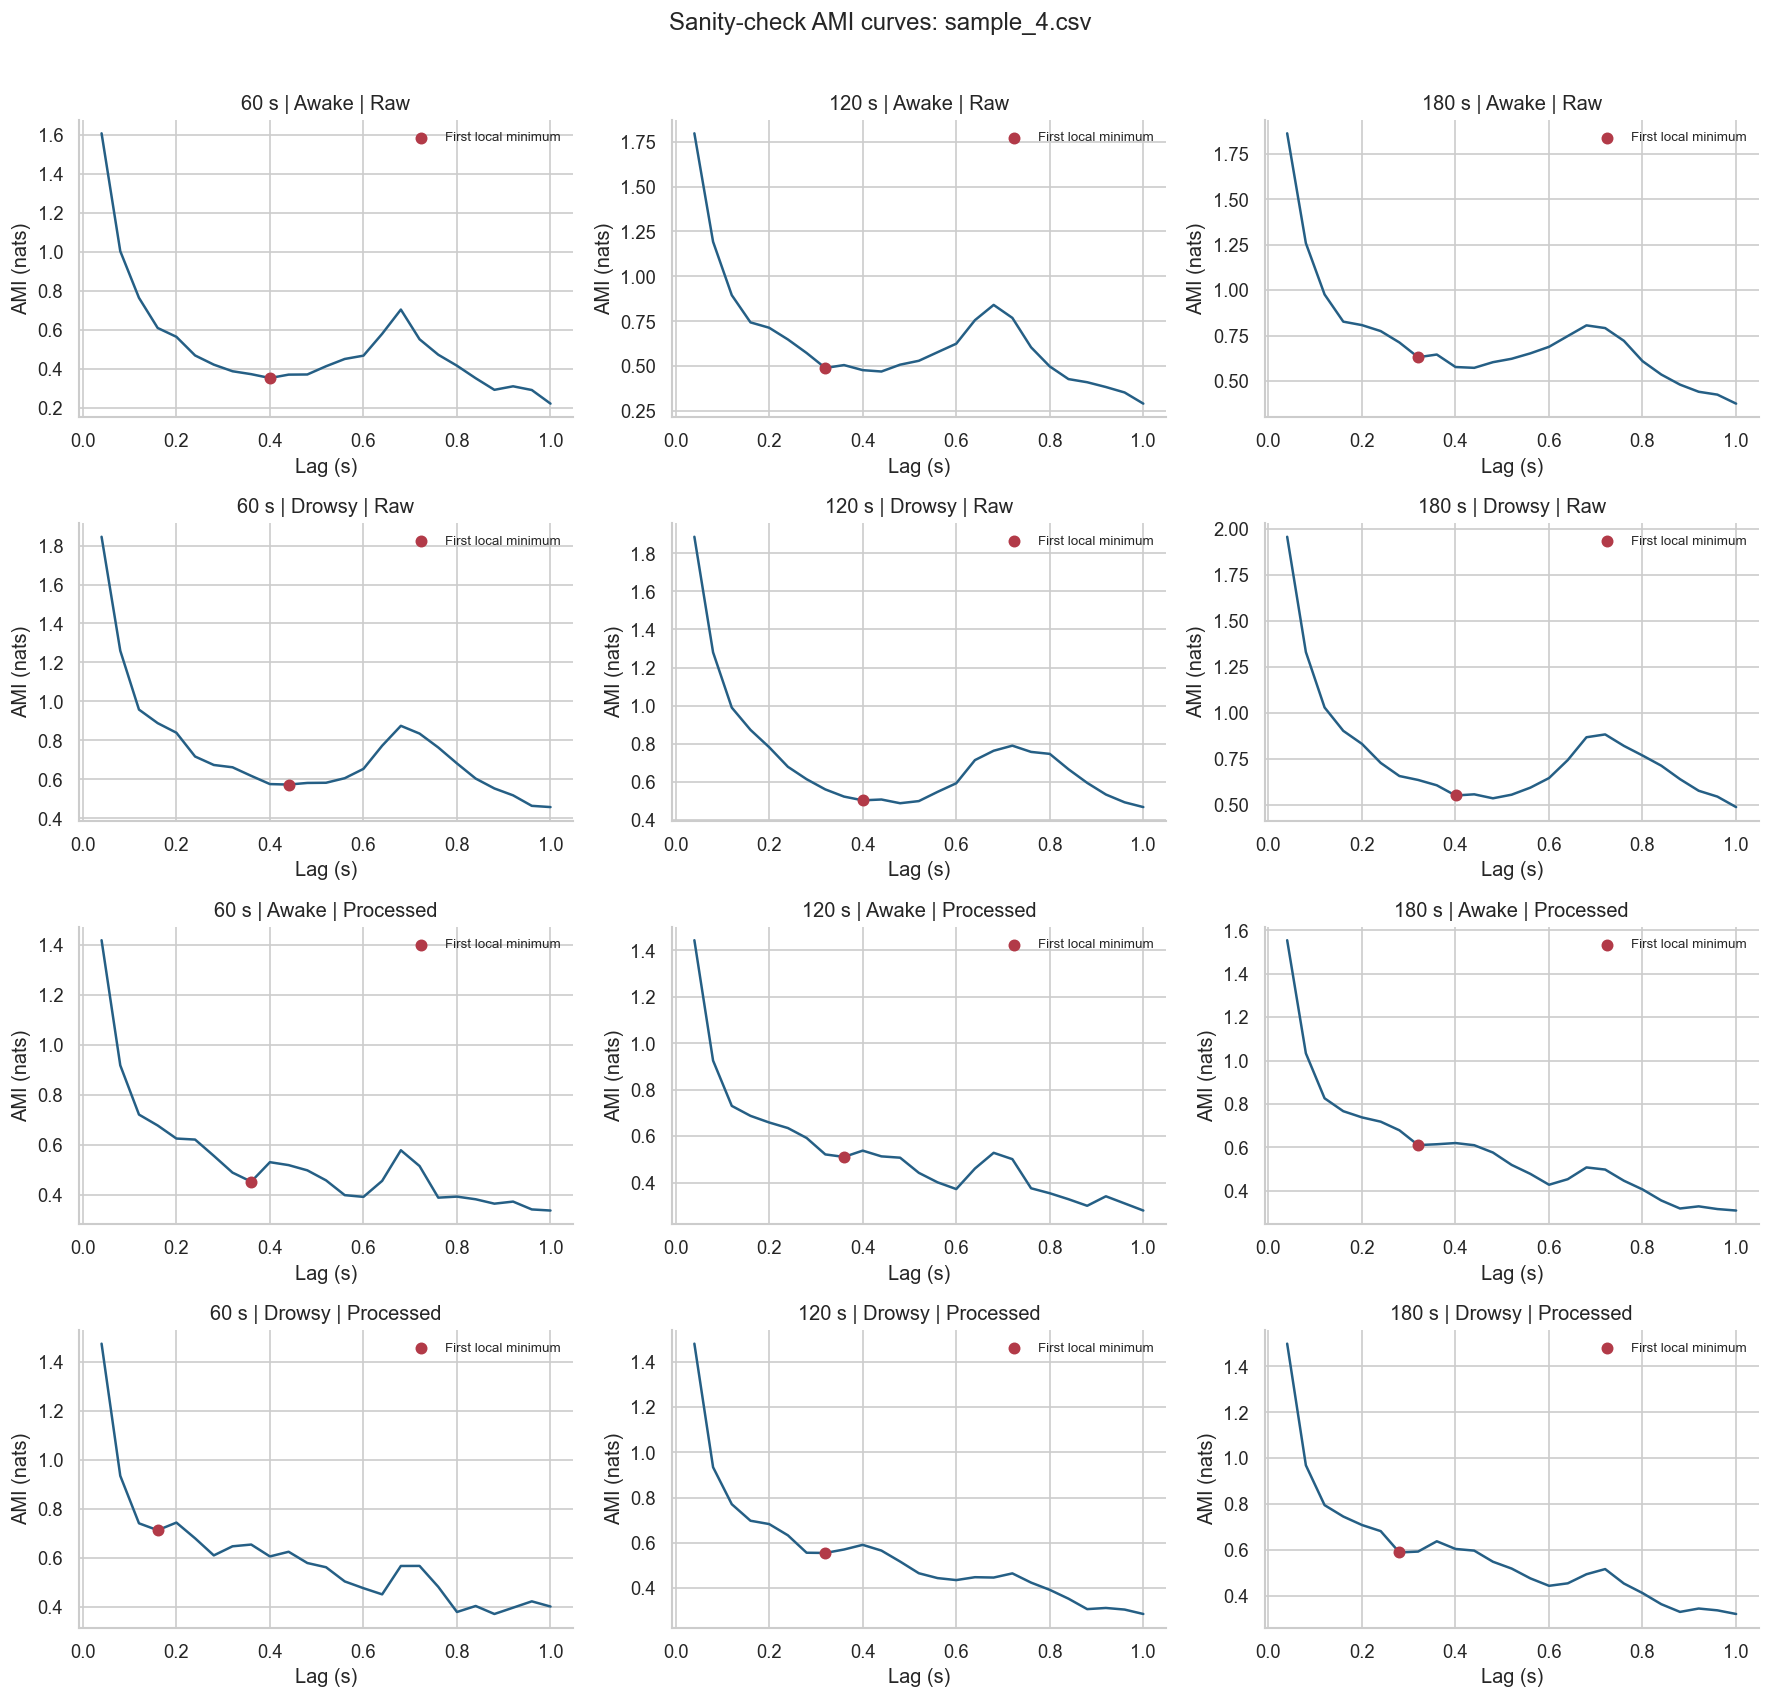

In [5]:
representative_curves = {}
for curve in sanity_curves:
    key = (
        curve["window_size_s"],
        curve["label"],
        curve["representation"],
    )
    representative_curves.setdefault(key, curve)

fig, axes = plt.subplots(4, 3, figsize=(15, 14), sharex=False)
for axis, curve in zip(axes.flat, representative_curves.values()):
    lag_seconds = curve["lags"] / curve["fs"]
    axis.plot(lag_seconds, curve["ami"], color="#255f85", linewidth=1.5)
    if curve["tau_found"]:
        axis.scatter(
            curve["tau_seconds"],
            curve["ami_at_tau"],
            color="#b23a48",
            s=38,
            zorder=3,
            label="First local minimum",
        )
        axis.legend(frameon=False, fontsize=8)
    axis.set_title(
        f"{curve['window_size_s']} s | {curve['label']} | "
        f"{curve['representation']}"
    )
    axis.set_xlabel("Lag (s)")
    axis.set_ylabel("AMI (nats)")

fig.suptitle(f"Sanity-check AMI curves: {sanity_session}", y=1.01)
fig.tight_layout()
plt.show()

## 2. Primary AMI analysis on the full dataset

One record is retained for every stationary window and representation. The run
is checkpointed after each session. An existing complete CSV is reused unless
`FORCE_RECOMPUTE` is set to `True`.

In [6]:
RESULT_COLUMNS = [
    "session",
    "window_id",
    "window_size_s",
    "label",
    "representation",
    "fs",
    "tau_samples",
    "tau_seconds",
    "ami_at_tau",
    "tau_found",
    "max_lag_samples",
]


def expected_result_count():
    "Return the expected number of primary result rows."
    raw = int(index["stationarity_pass_raw"].sum())
    processed = int(index["stationarity_pass_processed"].sum())
    return raw + processed


def cached_results_are_complete(path):
    "Check whether a cached result file is complete."
    if not path.is_file():
        return False
    cached = pd.read_csv(path)
    required = set(RESULT_COLUMNS)
    return required.issubset(cached.columns) and (
        len(cached) == expected_result_count()
    )


def run_full_dataset():
    "Run the primary AMI analysis for all sessions."
    chunks = []
    for number, session in enumerate(sessions, start=1):
        session_results, _ = run_ami_rows(iter_session_windows(session))
        chunks.append(session_results)
        checkpoint = pd.concat(chunks, ignore_index=True)
        checkpoint[RESULT_COLUMNS].to_csv(WINDOW_RESULTS_PATH, index=False)
        print(f"Completed {number:02d}/{len(sessions)}: {session}")
    return pd.concat(chunks, ignore_index=True)[RESULT_COLUMNS]


if FORCE_RECOMPUTE or not cached_results_are_complete(WINDOW_RESULTS_PATH):
    ami_results = run_full_dataset()
else:
    ami_results = pd.read_csv(WINDOW_RESULTS_PATH)
    if not pd.api.types.is_bool_dtype(ami_results["tau_found"]):
        ami_results["tau_found"] = (
            ami_results["tau_found"]
            .astype(str)
            .str.lower()
            .map({"true": True, "false": False})
        )
    print(f"Loaded complete cache: {WINDOW_RESULTS_PATH.name}")

assert len(ami_results) == expected_result_count()
assert set(ami_results["session"]) == set(sessions)
display(ami_results.head())
print(f"Saved: {WINDOW_RESULTS_PATH}")

Loaded complete cache: ami_window_results.csv


,session,window_id,window_size_s,label,representation,fs,tau_samples,tau_seconds,ami_at_tau,tau_found,max_lag_samples
0,sample_1.csv,3,60,Awake,Raw,50.0,13,0.26,1.130728,True,50
1,sample_1.csv,4,60,Awake,Raw,50.0,18,0.36,0.814999,True,50
2,sample_1.csv,5,60,Awake,Raw,50.0,22,0.44,0.875908,True,50
3,sample_1.csv,6,60,Awake,Raw,50.0,21,0.42,0.728852,True,50
4,sample_1.csv,8,60,Awake,Raw,50.0,16,0.32,1.031543,True,50


Saved: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\ami\ami_window_results.csv


## 3. Coverage and failure analysis

Coverage is summarized by window size, state, and representation. A second
table identifies sessions with the largest numbers of missing minima.

In [7]:
coverage = (
    ami_results
    .groupby(
        ["window_size_s", "label", "representation"],
        observed=True,
    )
    .agg(
        n_windows=("tau_found", "size"),
        n_tau_found=("tau_found", "sum"),
    )
    .reset_index()
)
coverage["n_tau_none"] = coverage["n_windows"] - coverage["n_tau_found"]
coverage["success_rate_pct"] = (
    100.0 * coverage["n_tau_found"] / coverage["n_windows"]
)
display(coverage)

failure_by_session = (
    ami_results
    .assign(tau_none=lambda frame: ~frame["tau_found"])
    .groupby("session", observed=True)
    .agg(
        n_windows=("tau_none", "size"),
        n_tau_none=("tau_none", "sum"),
    )
    .assign(
        failure_rate_pct=lambda frame: (
            100.0 * frame["n_tau_none"] / frame["n_windows"]
        )
    )
    .sort_values("failure_rate_pct", ascending=False)
    .reset_index()
)
display(failure_by_session.head(10))

,window_size_s,label,representation,n_windows,n_tau_found,n_tau_none,success_rate_pct
0,60,Awake,Processed,596,596,0,100.0
1,60,Awake,Raw,550,550,0,100.0
2,60,Drowsy,Processed,305,305,0,100.0
3,60,Drowsy,Raw,267,267,0,100.0
4,120,Awake,Processed,269,269,0,100.0
5,120,Awake,Raw,245,245,0,100.0
6,120,Drowsy,Processed,136,136,0,100.0
7,120,Drowsy,Raw,118,118,0,100.0
8,180,Awake,Processed,161,161,0,100.0
9,180,Awake,Raw,147,147,0,100.0


,session,n_windows,n_tau_none,failure_rate_pct
0,sample_1.csv,80,0,0.0
1,sample_10.csv,121,0,0.0
2,sample_8.csv,161,0,0.0
3,sample_7.csv,156,0,0.0
4,sample_6.csv,163,0,0.0
5,sample_5.csv,138,0,0.0
6,sample_4.csv,158,0,0.0
7,sample_25.csv,142,0,0.0
8,sample_23.csv,184,0,0.0
9,sample_22.csv,144,0,0.0


## 4. Window-level tau distributions

All cross-session comparisons use seconds. The summary reports the median,
IQR, minimum, and maximum among windows where a first minimum was found.

In [8]:
found_results = ami_results[ami_results["tau_found"]].copy()

window_distribution = (
    found_results
    .groupby(
        ["window_size_s", "label", "representation"],
        observed=True,
    )["tau_seconds"]
    .agg(
        n="size",
        median_tau_seconds="median",
        q1=lambda values: values.quantile(0.25),
        q3=lambda values: values.quantile(0.75),
        min_tau_seconds="min",
        max_tau_seconds="max",
    )
    .reset_index()
)
window_distribution["iqr_tau_seconds"] = (
    window_distribution["q3"] - window_distribution["q1"]
)
display(window_distribution)

,window_size_s,label,representation,n,median_tau_seconds,q1,q3,min_tau_seconds,max_tau_seconds,iqr_tau_seconds
0,60,Awake,Processed,596,0.160024,0.120030,0.260000,0.080000,0.720072,0.139970
1,60,Awake,Raw,550,0.200033,0.160040,0.280070,0.120018,0.600150,0.120030
2,60,Drowsy,Processed,305,0.120051,0.120020,0.160044,0.119988,0.559944,0.040024
3,60,Drowsy,Raw,267,0.200033,0.160046,0.280024,0.120012,0.640160,0.119978
4,120,Awake,Processed,269,0.160028,0.120030,0.319968,0.119988,0.680194,0.199938
5,120,Awake,Raw,245,0.200055,0.160041,0.320032,0.120031,0.640064,0.159991
6,120,Drowsy,Processed,136,0.120051,0.120018,0.160046,0.119988,0.559944,0.040027
7,120,Drowsy,Raw,118,0.200050,0.199995,0.319994,0.159996,0.560140,0.119999
8,180,Awake,Processed,161,0.160040,0.120030,0.319992,0.119988,0.680068,0.199962
9,180,Awake,Raw,147,0.200055,0.160052,0.320098,0.159984,0.600150,0.160046


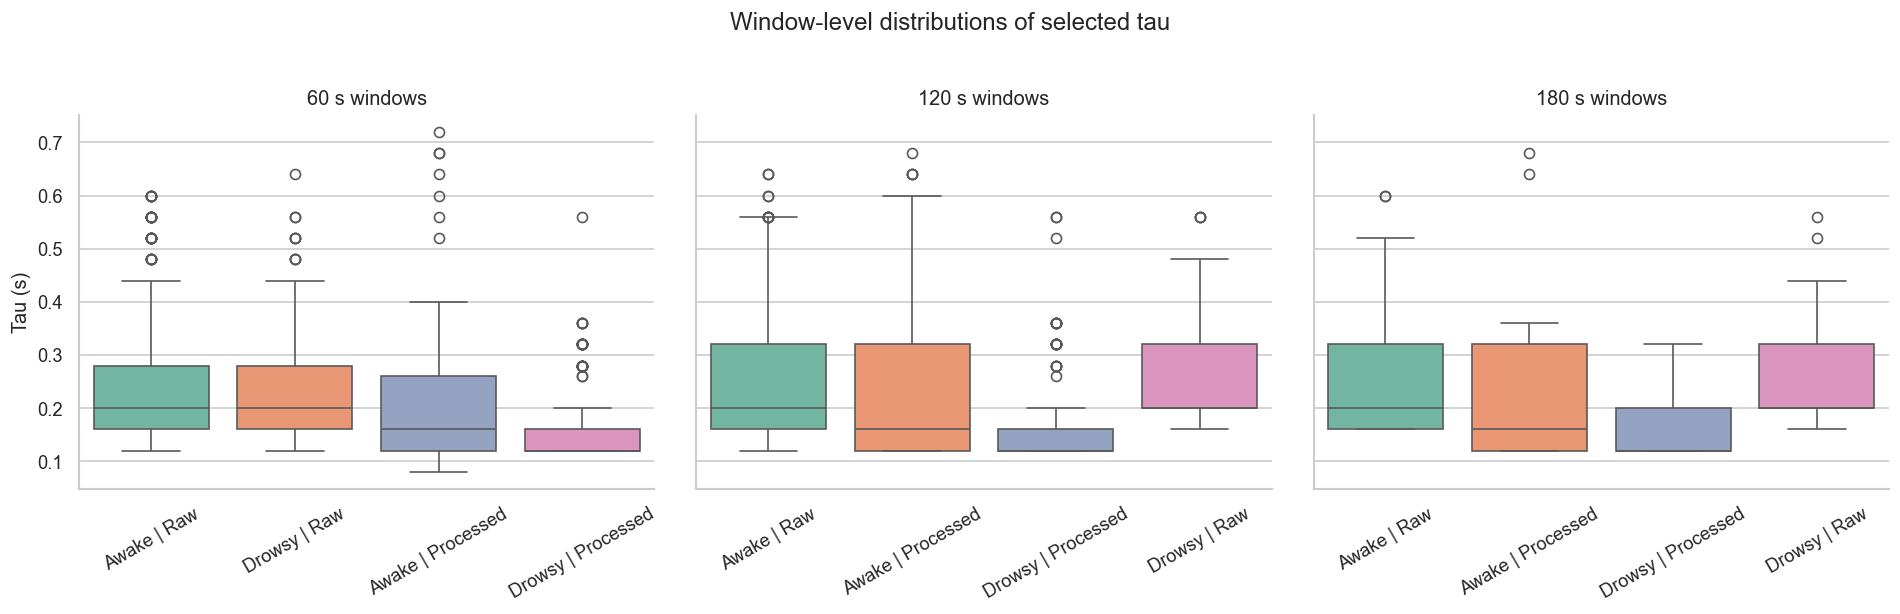

In [9]:
plot_data = found_results.copy()
plot_data["group"] = (
    plot_data["label"] + " | " + plot_data["representation"]
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for axis, window_size in zip(axes, WINDOW_SIZES):
    subset = plot_data[plot_data["window_size_s"] == window_size]
    sns.boxplot(
        data=subset,
        x="group",
        y="tau_seconds",
        hue="group",
        palette="Set2",
        legend=False,
        showfliers=True,
        ax=axis,
    )
    axis.set_title(f"{window_size} s windows")
    axis.set_xlabel("")
    axis.set_ylabel("Tau (s)" if window_size == 60 else "")
    axis.tick_params(axis="x", rotation=30)

fig.suptitle("Window-level distributions of selected tau", y=1.02)
fig.tight_layout()
plt.show()

## 5. Session-level aggregation

The session is the observational unit for downstream comparisons. Medians and
IQRs are calculated within each session/size/state/representation group.

In [10]:
SESSION_GROUPS = [
    "session",
    "window_size_s",
    "label",
    "representation",
]

session_summary = (
    ami_results
    .groupby(SESSION_GROUPS, observed=True)
    .apply(summarize_group, include_groups=False)
    .reset_index()
)
count_columns = ["n_windows", "n_tau_found"]
session_summary[count_columns] = session_summary[count_columns].astype(int)
session_summary.to_csv(SESSION_SUMMARY_PATH, index=False)

display(session_summary.head(12))
print(f"Rows: {len(session_summary)}")
print(f"Saved: {SESSION_SUMMARY_PATH}")

,session,window_size_s,label,representation,n_windows,n_tau_found,median_tau_seconds,iqr_tau_seconds,tau_found_rate
0,sample_1.csv,60,Awake,Processed,24,24,0.250000,0.165000,100.0
1,sample_1.csv,60,Awake,Raw,14,14,0.380000,0.100000,100.0
2,sample_1.csv,60,Drowsy,Processed,7,7,0.260000,0.110000,100.0
3,sample_1.csv,60,Drowsy,Raw,3,3,0.380000,0.020000,100.0
4,sample_1.csv,120,Awake,Processed,11,11,0.260000,0.150000,100.0
5,sample_1.csv,120,Awake,Raw,8,8,0.400000,0.045000,100.0
6,sample_1.csv,120,Drowsy,Processed,1,1,0.260000,0.000000,100.0
7,sample_1.csv,180,Awake,Processed,6,6,0.190000,0.155000,100.0
8,sample_1.csv,180,Awake,Raw,5,5,0.420000,0.020000,100.0
9,sample_1.csv,180,Drowsy,Processed,1,1,0.260000,0.000000,100.0


Rows: 238
Saved: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\ami\ami_session_summary.csv


## 6. Awake versus Drowsy

Only paired sessions with a valid session-level median in both states are used
within the same window size and representation. Differences are defined as
`Drowsy - Awake`.

In [11]:
state_pairs = (
    session_summary
    .pivot_table(
        index=["session", "window_size_s", "representation"],
        columns="label",
        values="median_tau_seconds",
    )
    .dropna(subset=["Awake", "Drowsy"])
    .reset_index()
)
state_pairs["difference_seconds"] = (
    state_pairs["Drowsy"] - state_pairs["Awake"]
)

awake_drowsy_summary = (
    state_pairs
    .groupby(["window_size_s", "representation"], observed=True)
    ["difference_seconds"]
    .agg(
        n_sessions="size",
        median_difference_seconds="median",
        q1=lambda values: values.quantile(0.25),
        q3=lambda values: values.quantile(0.75),
        n_drowsy_higher=lambda values: int((values > 0).sum()),
        n_equal=lambda values: int((values == 0).sum()),
        n_drowsy_lower=lambda values: int((values < 0).sum()),
    )
    .reset_index()
)
awake_drowsy_summary["iqr_difference_seconds"] = (
    awake_drowsy_summary["q3"] - awake_drowsy_summary["q1"]
)
display(awake_drowsy_summary)

,window_size_s,representation,n_sessions,median_difference_seconds,q1,q3,n_drowsy_higher,n_equal,n_drowsy_lower,iqr_difference_seconds
0,60,Processed,20,0.0,-0.040005,0.000000,2,10,8,0.040005
1,60,Raw,20,0.0,0.000000,0.010001,5,11,4,0.010001
2,120,Processed,20,0.0,-0.050007,0.000000,0,13,7,0.050007
3,120,Raw,19,0.0,-0.040008,0.030004,9,3,7,0.070012
4,180,Processed,20,0.0,-0.045007,0.000000,3,9,8,0.045007
5,180,Raw,19,0.0,-0.039998,0.030006,6,6,7,0.070003


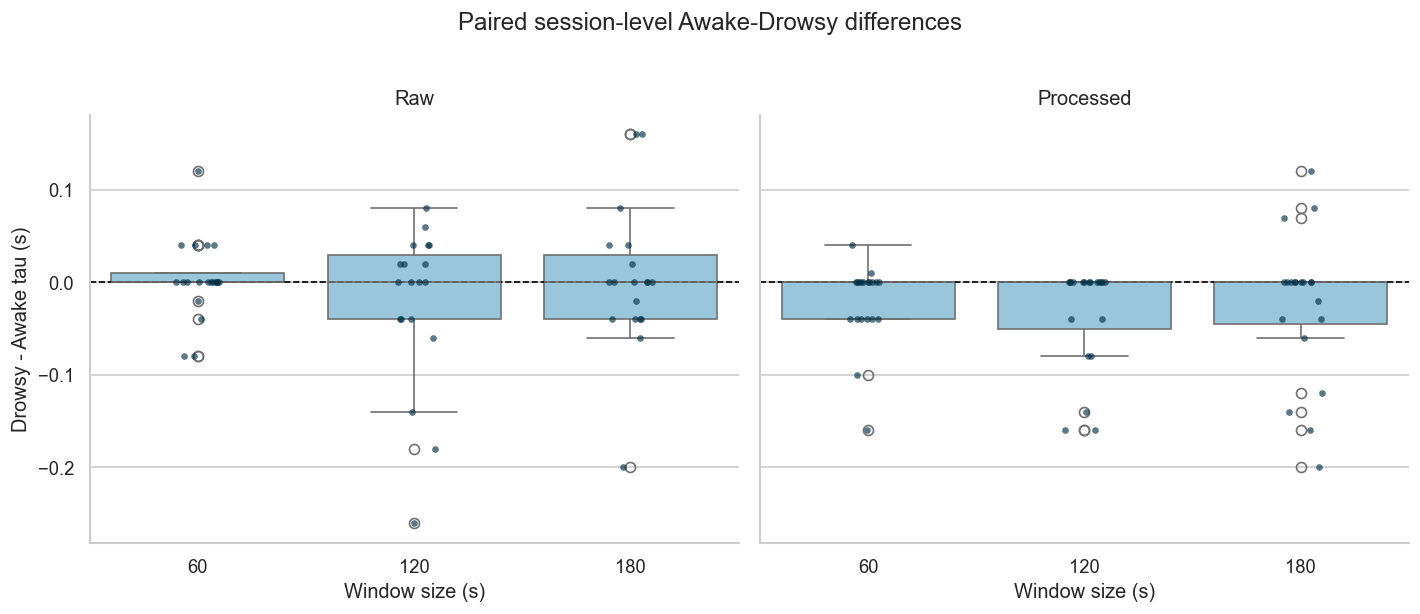

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for axis, representation in zip(axes, ("Raw", "Processed")):
    subset = state_pairs[state_pairs["representation"] == representation]
    sns.boxplot(
        data=subset,
        x="window_size_s",
        y="difference_seconds",
        color="#8ecae6",
        ax=axis,
    )
    sns.stripplot(
        data=subset,
        x="window_size_s",
        y="difference_seconds",
        color="#023047",
        alpha=0.65,
        size=4,
        ax=axis,
    )
    axis.axhline(0.0, color="black", linewidth=1, linestyle="--")
    axis.set_title(representation)
    axis.set_xlabel("Window size (s)")
    axis.set_ylabel("Drowsy - Awake tau (s)" if representation == "Raw" else "")

fig.suptitle("Paired session-level Awake-Drowsy differences", y=1.02)
fig.tight_layout()
plt.show()

## 7. Raw versus Processed

The comparison uses the inner intersection of window IDs that passed the
representation-specific stationarity filters. Differences are defined as
`Processed - Raw`; near agreement means a difference of at most one sample.

In [13]:
PAIR_KEYS = ["session", "window_id", "window_size_s", "label", "fs"]
raw_tau = ami_results[ami_results["representation"] == "Raw"]
processed_tau = ami_results[ami_results["representation"] == "Processed"]

representation_pairs = raw_tau.merge(
    processed_tau,
    on=PAIR_KEYS,
    suffixes=("_raw", "_processed"),
    validate="one_to_one",
)
representation_pairs = representation_pairs[
    representation_pairs["tau_found_raw"]
    & representation_pairs["tau_found_processed"]
].copy()
representation_pairs["difference_seconds"] = (
    representation_pairs["tau_seconds_processed"]
    - representation_pairs["tau_seconds_raw"]
)
representation_pairs["difference_samples"] = (
    representation_pairs["tau_samples_processed"]
    - representation_pairs["tau_samples_raw"]
)


def summarize_representation_pair(group):
    "Summarize matched Raw and Processed tau estimates."
    difference = group["difference_seconds"]
    correlation = group[
        ["tau_seconds_raw", "tau_seconds_processed"]
    ].corr().iloc[0, 1]
    return pd.Series({
        "n_pairs": len(group),
        "correlation": correlation,
        "median_difference_seconds": difference.median(),
        "iqr_difference_seconds": (
            difference.quantile(0.75) - difference.quantile(0.25)
        ),
        "exact_agreement_pct": 100.0 * (
            group["difference_samples"] == 0
        ).mean(),
        "near_agreement_pct": 100.0 * (
            group["difference_samples"].abs() <= 1
        ).mean(),
    })


raw_processed_summary = (
    representation_pairs
    .groupby(["window_size_s", "label"], observed=True)
    .apply(summarize_representation_pair, include_groups=False)
    .reset_index()
)
display(raw_processed_summary)

,window_size_s,label,n_pairs,correlation,median_difference_seconds,iqr_difference_seconds,exact_agreement_pct,near_agreement_pct
0,60,Awake,542.0,0.448444,-0.040007,0.080013,18.819188,57.933579
1,60,Drowsy,260.0,0.276912,-0.040013,0.040035,13.076923,53.076923
2,120,Awake,241.0,0.478465,-0.040010,0.080031,11.203320,49.377593
3,120,Drowsy,113.0,0.334664,-0.079999,0.080016,9.734513,38.053097
4,180,Awake,145.0,0.640713,-0.040010,0.120000,15.172414,57.931034
5,180,Drowsy,66.0,0.377573,-0.080008,0.040033,13.636364,36.363636


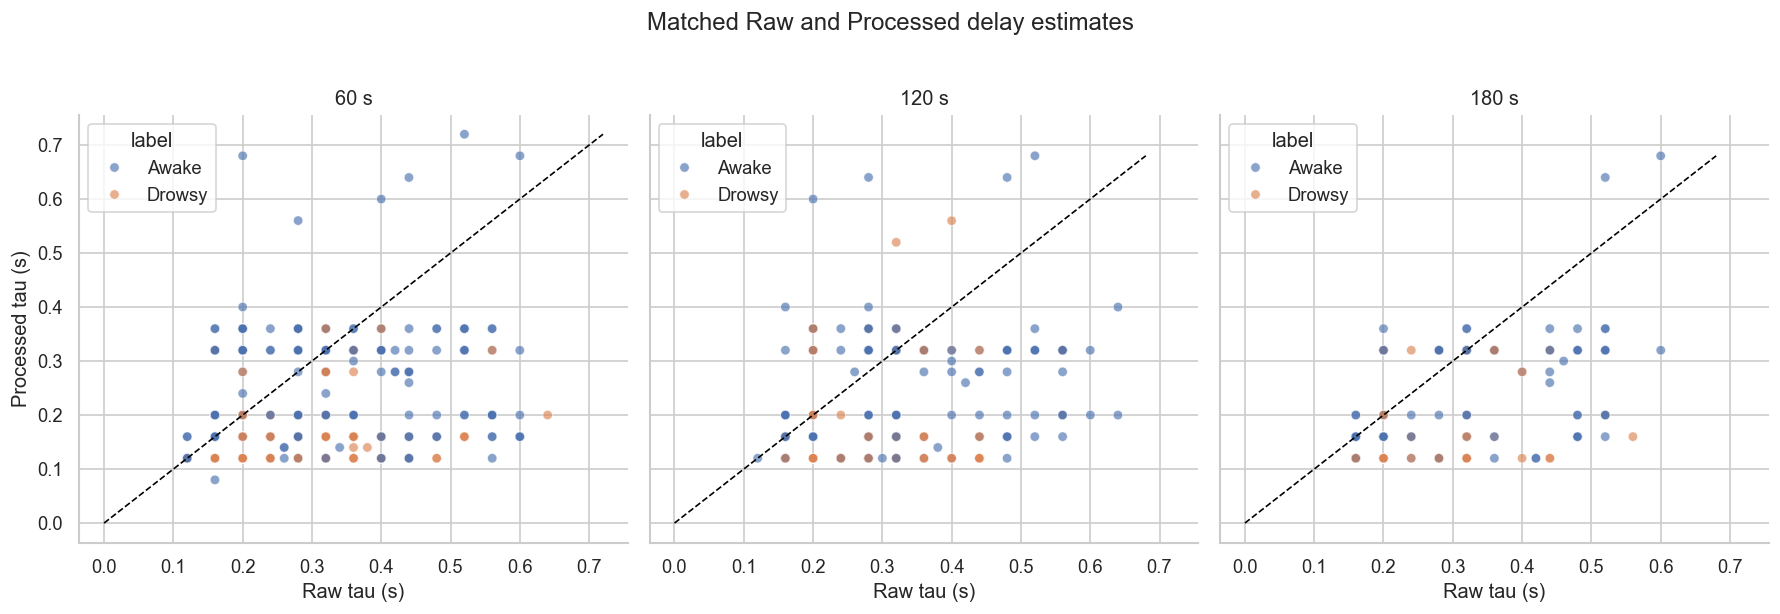

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for axis, window_size in zip(axes, WINDOW_SIZES):
    subset = representation_pairs[
        representation_pairs["window_size_s"] == window_size
    ]
    sns.scatterplot(
        data=subset,
        x="tau_seconds_raw",
        y="tau_seconds_processed",
        hue="label",
        alpha=0.65,
        s=32,
        ax=axis,
    )
    limits = [
        0.0,
        max(
            subset["tau_seconds_raw"].max(),
            subset["tau_seconds_processed"].max(),
        ),
    ]
    axis.plot(limits, limits, color="black", linestyle="--", linewidth=1)
    axis.set_title(f"{window_size} s")
    axis.set_xlabel("Raw tau (s)")
    axis.set_ylabel("Processed tau (s)" if window_size == 60 else "")

fig.suptitle("Matched Raw and Processed delay estimates", y=1.02)
fig.tight_layout()
plt.show()

## 8. Window-size stability

The analysis retains sessions with valid medians at all three window sizes for
the same state and representation. Pairwise differences use seconds.

In [17]:
SENSITIVITY_KEYS = [
    "session",
    "window_size_s",
    "label",
    "representation",
]

sensitivity_cohort = (
    ami_results
    .sort_values(SENSITIVITY_KEYS + ["window_id"])
    .groupby(SENSITIVITY_KEYS, observed=True)
    .head(1)
    .reset_index(drop=True)
)


def selected_signal(row, cache):
    "Load one selected signal and reuse session batches."
    representation = row["representation"].lower()
    cache_key = (row["session"], representation)
    if cache_key not in cache:
        cache[cache_key] = get_data(
            row["session"],
            data_dir=DATA_DIR,
            stationarity=representation,
        )

    awake, drowsy = cache[cache_key]
    state_data = awake if row["label"] == "Awake" else drowsy
    batch = state_data[int(row["window_size_s"])]
    matches = np.flatnonzero(batch["window_id"] == row["window_id"])
    if len(matches) != 1:
        raise ValueError("Selected window ID is not unique.")
    return batch[representation][matches[0]]


def run_sensitivity(configurations, config_name):
    "Run AMI configurations on the stratified cohort."
    records = []
    cache = {}
    for _, row in sensitivity_cohort.iterrows():
        signal = selected_signal(row, cache)
        for config_value, k, max_lag_seconds in configurations:
            result = estimate_window(signal, row["fs"], k, max_lag_seconds)
            records.append({
                **{key: row[key] for key in SENSITIVITY_KEYS},
                "window_id": int(row["window_id"]),
                "fs": row["fs"],
                config_name: config_value,
                "tau_samples": result["tau_samples"],
                "tau_seconds": result["tau_seconds"],
                "tau_found": result["tau_found"],
            })
    return pd.DataFrame(records)


print(f"Sensitivity cohort windows: {len(sensitivity_cohort)}")
display(
    sensitivity_cohort
    .groupby(["window_size_s", "label", "representation"])
    .size()
    .rename("n_windows")
    .reset_index()
)

Sensitivity cohort windows: 238


,window_size_s,label,representation,n_windows
0,60,Awake,Processed,20
1,60,Awake,Raw,20
2,60,Drowsy,Processed,20
3,60,Drowsy,Raw,20
4,120,Awake,Processed,20
5,120,Awake,Raw,20
6,120,Drowsy,Processed,20
7,120,Drowsy,Raw,19
8,180,Awake,Processed,20
9,180,Awake,Raw,20


### KSG neighbor-count sensitivity

Each `k` is compared with the primary value `k=3`. Agreement requires equal
sample lags; absolute differences are reported in seconds.

In [18]:
k_configurations = [
    (k, k, MAX_LAG_SECONDS)
    for k in K_VALUES
]
k_sensitivity = run_sensitivity(k_configurations, "k")

k_pivot = k_sensitivity.pivot_table(
    index=SENSITIVITY_KEYS + ["window_id", "fs"],
    columns="k",
    values=["tau_samples", "tau_seconds"],
)

k_rows = []
for k in K_VALUES:
    k_subset = k_sensitivity[k_sensitivity["k"] == k]
    if k == K_MAIN:
        k_rows.append({
            "k": k,
            "n_windows": len(k_subset),
            "tau_found_rate_pct": 100.0 * k_subset["tau_found"].mean(),
            "n_paired_with_k3": int(k_subset["tau_found"].sum()),
            "agreement_with_k3_pct": 100.0,
            "median_abs_delta_seconds": 0.0,
        })
        continue

    candidate = k_pivot[[
        ("tau_samples", K_MAIN),
        ("tau_samples", k),
        ("tau_seconds", K_MAIN),
        ("tau_seconds", k),
    ]].dropna()
    sample_difference = (
        candidate[("tau_samples", k)]
        - candidate[("tau_samples", K_MAIN)]
    )
    second_difference = (
        candidate[("tau_seconds", k)]
        - candidate[("tau_seconds", K_MAIN)]
    ).abs()
    k_rows.append({
        "k": k,
        "n_windows": len(k_subset),
        "tau_found_rate_pct": 100.0 * k_subset["tau_found"].mean(),
        "n_paired_with_k3": len(candidate),
        "agreement_with_k3_pct": 100.0 * (sample_difference == 0).mean(),
        "median_abs_delta_seconds": second_difference.median(),
    })

k_sensitivity_summary = pd.DataFrame(k_rows)
display(k_sensitivity_summary)

,k,n_windows,tau_found_rate_pct,n_paired_with_k3,agreement_with_k3_pct,median_abs_delta_seconds
0,2,238,100.0,238,68.067227,0.0
1,3,238,100.0,238,100.000000,0.0
2,4,238,100.0,238,77.731092,0.0


### Physical search-range sensitivity

The main `1.0 s` range is compared with `0.5 s` and `1.5 s`. This tests whether
the selected first minimum is primarily controlled by the search boundary.

In [19]:
lag_configurations = [
    (seconds, K_MAIN, seconds)
    for seconds in MAX_LAG_SENSITIVITY
]
lag_sensitivity = run_sensitivity(
    lag_configurations,
    "max_lag_seconds",
)

lag_pivot = lag_sensitivity.pivot_table(
    index=SENSITIVITY_KEYS + ["window_id", "fs"],
    columns="max_lag_seconds",
    values=["tau_samples", "tau_seconds"],
)

lag_rows = []
for seconds in MAX_LAG_SENSITIVITY:
    lag_subset = lag_sensitivity[
        lag_sensitivity["max_lag_seconds"] == seconds
    ]
    if seconds == MAX_LAG_SECONDS:
        lag_rows.append({
            "max_lag_seconds": seconds,
            "n_windows": len(lag_subset),
            "tau_found_rate_pct": 100.0 * lag_subset["tau_found"].mean(),
            "n_paired_with_main": int(lag_subset["tau_found"].sum()),
            "agreement_with_main_pct": 100.0,
            "median_abs_delta_seconds": 0.0,
        })
        continue

    candidate = lag_pivot[[
        ("tau_samples", MAX_LAG_SECONDS),
        ("tau_samples", seconds),
        ("tau_seconds", MAX_LAG_SECONDS),
        ("tau_seconds", seconds),
    ]].dropna()
    sample_difference = (
        candidate[("tau_samples", seconds)]
        - candidate[("tau_samples", MAX_LAG_SECONDS)]
    )
    second_difference = (
        candidate[("tau_seconds", seconds)]
        - candidate[("tau_seconds", MAX_LAG_SECONDS)]
    ).abs()
    lag_rows.append({
        "max_lag_seconds": seconds,
        "n_windows": len(lag_subset),
        "tau_found_rate_pct": 100.0 * lag_subset["tau_found"].mean(),
        "n_paired_with_main": len(candidate),
        "agreement_with_main_pct": 100.0 * (
            sample_difference == 0
        ).mean(),
        "median_abs_delta_seconds": second_difference.median(),
    })

lag_sensitivity_summary = pd.DataFrame(lag_rows)
display(lag_sensitivity_summary)

,max_lag_seconds,n_windows,tau_found_rate_pct,n_paired_with_main,agreement_with_main_pct,median_abs_delta_seconds
0,0.5,238,96.218487,229,100.0,0.0
1,1.0,238,100.000000,238,100.0,0.0
2,1.5,238,100.000000,238,100.0,0.0


## 10. Systematic visual validation

The selected set includes low, median, high, and missing tau cases when
available, plus paired Awake/Drowsy and Raw/Processed examples.

In [20]:
def append_unique(selection, name, row):
    "Append a labeled row unless the same role already exists."
    if row is None:
        return
    selected = row.to_dict()
    selected["selection"] = name
    selection.append(selected)


visual_rows = []
ordered_found = found_results.sort_values("tau_seconds")
append_unique(visual_rows, "Low tau", ordered_found.iloc[0])
median_index = (
    ordered_found["tau_seconds"]
    - ordered_found["tau_seconds"].median()
).abs().idxmin()
append_unique(visual_rows, "Median tau", ordered_found.loc[median_index])
append_unique(visual_rows, "High tau", ordered_found.iloc[-1])

missing = ami_results[~ami_results["tau_found"]]
append_unique(
    visual_rows,
    "Tau not found",
    None if missing.empty else missing.iloc[0],
)

state_example = state_pairs.iloc[0]
state_filter = (
    (found_results["session"] == state_example["session"])
    & (found_results["window_size_s"] == state_example["window_size_s"])
    & (found_results["representation"] == state_example["representation"])
)
for label in ("Awake", "Drowsy"):
    row = found_results[state_filter & (found_results["label"] == label)].iloc[0]
    append_unique(visual_rows, f"State pair: {label}", row)

representation_example = representation_pairs.iloc[0]
representation_filter = (
    (found_results["session"] == representation_example["session"])
    & (found_results["window_id"] == representation_example["window_id"])
    & (
        found_results["window_size_s"]
        == representation_example["window_size_s"]
    )
    & (found_results["label"] == representation_example["label"])
)
for representation in ("Raw", "Processed"):
    row = found_results[
        representation_filter
        & (found_results["representation"] == representation)
    ].iloc[0]
    append_unique(visual_rows, f"Representation pair: {representation}", row)

visual_selection = pd.DataFrame(visual_rows)
display(visual_selection[
    [
        "selection",
        "session",
        "window_id",
        "window_size_s",
        "label",
        "representation",
        "tau_seconds",
    ]
])

,selection,session,window_id,window_size_s,label,representation,tau_seconds
0,Low tau,sample_21.csv,2,60,Awake,Processed,0.080000
1,Median tau,sample_12.csv,5,180,Awake,Raw,0.160068
2,High tau,sample_23.csv,2,60,Awake,Processed,0.720072
3,State pair: Awake,sample_1.csv,1,60,Awake,Processed,0.300000
4,State pair: Drowsy,sample_1.csv,18,60,Drowsy,Processed,0.140000
5,Representation pair: Raw,sample_1.csv,3,60,Awake,Raw,0.260000
6,Representation pair: Processed,sample_1.csv,3,60,Awake,Processed,0.120000


## 11. Audit evidence and output files

The final cell reports the observed evidence for each freeze criterion without
discarding failures or interpreting AMI as proof of determinism.

In [22]:
overall_success = 100.0 * ami_results["tau_found"].mean()
state_failure_range = (
    coverage.groupby("label")["success_rate_pct"].mean().max()
    - coverage.groupby("label")["success_rate_pct"].mean().min()
)
size_stability_median = window_stability[
    "median_abs_difference_seconds"
].median()

evidence = pd.DataFrame({
    "criterion": [
        "First minimum coverage",
        "Finite sanity-check curves",
        "KSG k=2-4 stability",
        "max_lag stability",
        "Awake/Drowsy failure-rate spread",
        "60/120/180 s session stability",
        "Raw/Processed comparison",
    ],
    "observed_result": [
        f"{overall_success:.2f}% of windows",
        f"{len(sanity_curves)}/{len(sanity_curves)} curves finite",
        (
            f"median agreement with k=3: "
            f"{k_sensitivity_summary['agreement_with_k3_pct'].median():.2f}%"
        ),
        (
            f"median agreement with 1.0 s: "
            f"{lag_sensitivity_summary['agreement_with_main_pct'].median():.2f}%"
        ),
        f"{state_failure_range:.2f} percentage points",
        f"median |difference|: {size_stability_median:.4f} s",
        f"{len(representation_pairs)} matched valid windows",
    ],
})
display(evidence)

report = f'''
### Completed outputs

- Window-level results: `{WINDOW_RESULTS_PATH}`
- Session-level summary: `{SESSION_SUMMARY_PATH}`
- Primary configuration: `k={K_MAIN}`, `max_lag={MAX_LAG_SECONDS:.1f} s`
- Sessions: `{len(sessions)}`
- Window-representation records: `{len(ami_results)}`

AMI supplies an embedding-delay estimate for later nonlinear analyses. It does
not by itself establish deterministic or chaotic dynamics. Awake-Drowsy
differences are supporting evidence about temporal dependence scale, while the
Raw-Processed analysis measures preprocessing robustness rather than a Raw PPG
versus PPI research comparison.
'''
display(Markdown(report))

,criterion,observed_result
0,First minimum coverage,100.00% of windows
1,Finite sanity-check curves,158/158 curves finite
2,KSG k=2-4 stability,median agreement with k=3: 77.73%
3,max_lag stability,median agreement with 1.0 s: 100.00%
4,Awake/Drowsy failure-rate spread,0.00 percentage points
5,60/120/180 s session stability,median |difference|: 0.0000 s
6,Raw/Processed comparison,1367 matched valid windows



### Completed outputs

- Window-level results: `C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\ami\ami_window_results.csv`
- Session-level summary: `C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\ami\ami_session_summary.csv`
- Primary configuration: `k=3`, `max_lag=1.0 s`
- Sessions: `20`
- Window-representation records: `2942`

AMI supplies an embedding-delay estimate for later nonlinear analyses. It does
not by itself establish deterministic or chaotic dynamics. Awake-Drowsy
differences are supporting evidence about temporal dependence scale, while the
Raw-Processed analysis measures preprocessing robustness rather than a Raw PPG
versus PPI research comparison.


# Tổng kết các kết quả chính

## Cấu hình và dữ liệu

| Nội dung | Kết quả |
|---|---:|
| Số session | 20 |
| Window size | 60, 120 và 180 s |
| Trạng thái | Awake và Drowsy |
| Biểu diễn | Raw và Processed |
| Cấu hình chính | `k = 3`, `max_lag = 1.0 s` |
| Số window × representation | 2.942 |
| Số nhóm session-level | 238 |

## Sanity check và coverage

- Session sanity check: `sample_4.csv`.
- Số AMI curve hữu hạn: 158/158.
- Số window tìm thấy first local minimum: 2.942/2.942.
- Success rate ở cả 12 nhóm size × state × representation: 100%.
- Số trường hợp `tau=None`: 0.

## Phân phối tau ở window level

Median `tau_seconds`:

| Window | Awake Raw | Awake Processed | Drowsy Raw | Drowsy Processed |
|---:|---:|---:|---:|---:|
| 60 s | 0.2000 | 0.1600 | 0.2000 | 0.1201 |
| 120 s | 0.2001 | 0.1600 | 0.2001 | 0.1201 |
| 180 s | 0.2001 | 0.1600 | 0.2001 | 0.1201 |

Khoảng giá trị `tau_seconds` quan sát được: 0.0800–0.7201 s.

## So sánh session level

- Awake–Drowsy: median của `Drowsy - Awake` bằng 0.0000 s trong cả sáu cấu hình window size × representation.
- Số session ghép cặp Awake–Drowsy: 20 cho Processed; 20/19/19 cho Raw ở 60/120/180 s.
- Raw–Processed: 1.367 window ghép cặp hợp lệ.
- Tương quan Raw–Processed theo size × state: 0.2769–0.6407.
- Median `Processed - Raw`: từ -0.0800 đến -0.0400 s.
- Exact agreement: 9.73–18.82%; near agreement ±1 sample: 36.36–57.93%.
- Window-size stability: tương quan session-level 0.5634–0.9782; median absolute difference 0.0000–0.0200 s.

## Sensitivity analysis

Cohort sensitivity gồm 238 window được chọn theo session × size × state × representation.

| Cấu hình | Tau-found rate | Agreement với cấu hình chính | Median absolute delta |
|---|---:|---:|---:|
| `k = 2` | 100.00% | 68.07% | 0.0000 s |
| `k = 3` | 100.00% | 100.00% | 0.0000 s |
| `k = 4` | 100.00% | 77.73% | 0.0000 s |
| `max_lag = 0.5 s` | 96.22% | 100.00% trên các cặp tìm thấy tau | 0.0000 s |
| `max_lag = 1.0 s` | 100.00% | 100.00% | 0.0000 s |
| `max_lag = 1.5 s` | 100.00% | 100.00% | 0.0000 s |

## File kết quả

- `phase1/results/ami/ami_window_results.csv`
- `phase1/results/ami/ami_session_summary.csv`


# Phân tích kết quả AMI

Phân tích được thực hiện ở hai tầng:

```text
ami_window_results.csv
→ variability ở từng window

ami_session_summary.csv
→ inference chính ở session level
```

Các bảng và hình publication được lưu trong
`phase1/results/ami/analysis`.

In [3]:
from textwrap import dedent

from scipy.stats import spearmanr, wilcoxon


ANALYSIS_DIR = OUTPUT_DIR / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

analysis_window = pd.read_csv(WINDOW_RESULTS_PATH)
analysis_session = pd.read_csv(SESSION_SUMMARY_PATH)
sessions = sorted(
    analysis_window["session"].unique(),
    key=natural_key,
)


def parse_boolean(series):
    """Return a validated Boolean series."""
    if pd.api.types.is_bool_dtype(series):
        return series
    values = series.astype(str).str.strip().str.lower()
    result = values.map({"true": True, "false": False})
    if result.isna().any():
        raise ValueError("tau_found contains invalid values.")
    return result.astype(bool)


analysis_window["tau_found"] = parse_boolean(
    analysis_window["tau_found"]
)

WINDOW_KEYS = [
    "session",
    "window_size_s",
    "window_id",
    "representation",
]
SESSION_KEYS = [
    "session",
    "window_size_s",
    "label",
    "representation",
]
GROUP_KEYS = ["window_size_s", "label", "representation"]

print(f"Window-level rows: {len(analysis_window)}")
print(f"Session-level rows: {len(analysis_session)}")

Window-level rows: 2942
Session-level rows: 238


## 1. Data integrity và coverage

Kiểm tra coverage, khóa duy nhất, trạng thái tìm thấy `tau` và giới hạn
`max_lag_samples`.

In [4]:
required_window_columns = {
    "session",
    "window_id",
    "window_size_s",
    "label",
    "representation",
    "fs",
    "tau_samples",
    "tau_seconds",
    "ami_at_tau",
    "tau_found",
    "max_lag_samples",
}
required_session_columns = {
    "session",
    "window_size_s",
    "label",
    "representation",
    "n_windows",
    "median_tau_seconds",
    "iqr_tau_seconds",
    "tau_found_rate",
}

missing_window_columns = required_window_columns.difference(
    analysis_window.columns
)
missing_session_columns = required_session_columns.difference(
    analysis_session.columns
)
if missing_window_columns or missing_session_columns:
    raise ValueError(
        "Missing result columns: "
        f"window={sorted(missing_window_columns)}, "
        f"session={sorted(missing_session_columns)}"
    )

found_mask = analysis_window["tau_found"]
boundary_violations = (
    analysis_window.loc[found_mask, "tau_samples"]
    > analysis_window.loc[found_mask, "max_lag_samples"]
).sum()

integrity_summary = pd.DataFrame({
    "metric": [
        "Window-level rows",
        "Unique sessions",
        "Duplicate window keys",
        "Duplicate session keys",
        "Tau found",
        "Tau not found",
        "Tau above max lag",
    ],
    "value": [
        len(analysis_window),
        analysis_window["session"].nunique(),
        int(analysis_window.duplicated(WINDOW_KEYS).sum()),
        int(analysis_session.duplicated(SESSION_KEYS).sum()),
        int(found_mask.sum()),
        int((~found_mask).sum()),
        int(boundary_violations),
    ],
})

coverage_analysis = (
    analysis_window
    .groupby(GROUP_KEYS, observed=True)
    .agg(
        n_windows=("window_id", "size"),
        n_sessions=("session", "nunique"),
        n_tau_found=("tau_found", "sum"),
    )
    .reset_index()
)
coverage_analysis["n_tau_none"] = (
    coverage_analysis["n_windows"]
    - coverage_analysis["n_tau_found"]
)
coverage_analysis["success_rate_pct"] = (
    100.0
    * coverage_analysis["n_tau_found"]
    / coverage_analysis["n_windows"]
)

display(integrity_summary)
display(coverage_analysis)

,metric,value
0,Window-level rows,2942
1,Unique sessions,20
2,Duplicate window keys,0
3,Duplicate session keys,0
4,Tau found,2942
5,Tau not found,0
6,Tau above max lag,0


,window_size_s,label,representation,n_windows,n_sessions,n_tau_found,n_tau_none,success_rate_pct
0,60,Awake,Processed,596,20,596,0,100.0
1,60,Awake,Raw,550,20,550,0,100.0
2,60,Drowsy,Processed,305,20,305,0,100.0
3,60,Drowsy,Raw,267,20,267,0,100.0
4,120,Awake,Processed,269,20,269,0,100.0
5,120,Awake,Raw,245,20,245,0,100.0
6,120,Drowsy,Processed,136,20,136,0,100.0
7,120,Drowsy,Raw,118,19,118,0,100.0
8,180,Awake,Processed,161,20,161,0,100.0
9,180,Awake,Raw,147,20,147,0,100.0


## 2. Phân phối tau toàn dataset

Bảng 1 sử dụng `tau_seconds` để so sánh các session có sampling rate
khác nhau.

In [5]:
found_window = analysis_window[analysis_window["tau_found"]].copy()

table_1_tau_distribution = (
    found_window
    .groupby(GROUP_KEYS, observed=True)["tau_seconds"]
    .agg(
        n="size",
        median_tau_seconds="median",
        q1_tau_seconds=lambda values: values.quantile(0.25),
        q3_tau_seconds=lambda values: values.quantile(0.75),
        min_tau_seconds="min",
        max_tau_seconds="max",
    )
    .reset_index()
)
table_1_tau_distribution["iqr_tau_seconds"] = (
    table_1_tau_distribution["q3_tau_seconds"]
    - table_1_tau_distribution["q1_tau_seconds"]
)
table_1_tau_distribution.to_csv(
    ANALYSIS_DIR / "table_1_tau_distribution.csv",
    index=False,
)
display(table_1_tau_distribution)

,window_size_s,label,representation,n,median_tau_seconds,q1_tau_seconds,q3_tau_seconds,min_tau_seconds,max_tau_seconds,iqr_tau_seconds
0,60,Awake,Processed,596,0.160024,0.120030,0.260000,0.080000,0.720072,0.139970
1,60,Awake,Raw,550,0.200033,0.160040,0.280070,0.120018,0.600150,0.120030
2,60,Drowsy,Processed,305,0.120051,0.120020,0.160044,0.119988,0.559944,0.040024
3,60,Drowsy,Raw,267,0.200033,0.160046,0.280024,0.120012,0.640160,0.119978
4,120,Awake,Processed,269,0.160028,0.120030,0.319968,0.119988,0.680194,0.199938
5,120,Awake,Raw,245,0.200055,0.160041,0.320032,0.120031,0.640064,0.159991
6,120,Drowsy,Processed,136,0.120051,0.120018,0.160046,0.119988,0.559944,0.040027
7,120,Drowsy,Raw,118,0.200050,0.199995,0.319994,0.159996,0.560140,0.119999
8,180,Awake,Processed,161,0.160040,0.120030,0.319992,0.119988,0.680068,0.199962
9,180,Awake,Raw,147,0.200055,0.160052,0.320098,0.159984,0.600150,0.160046


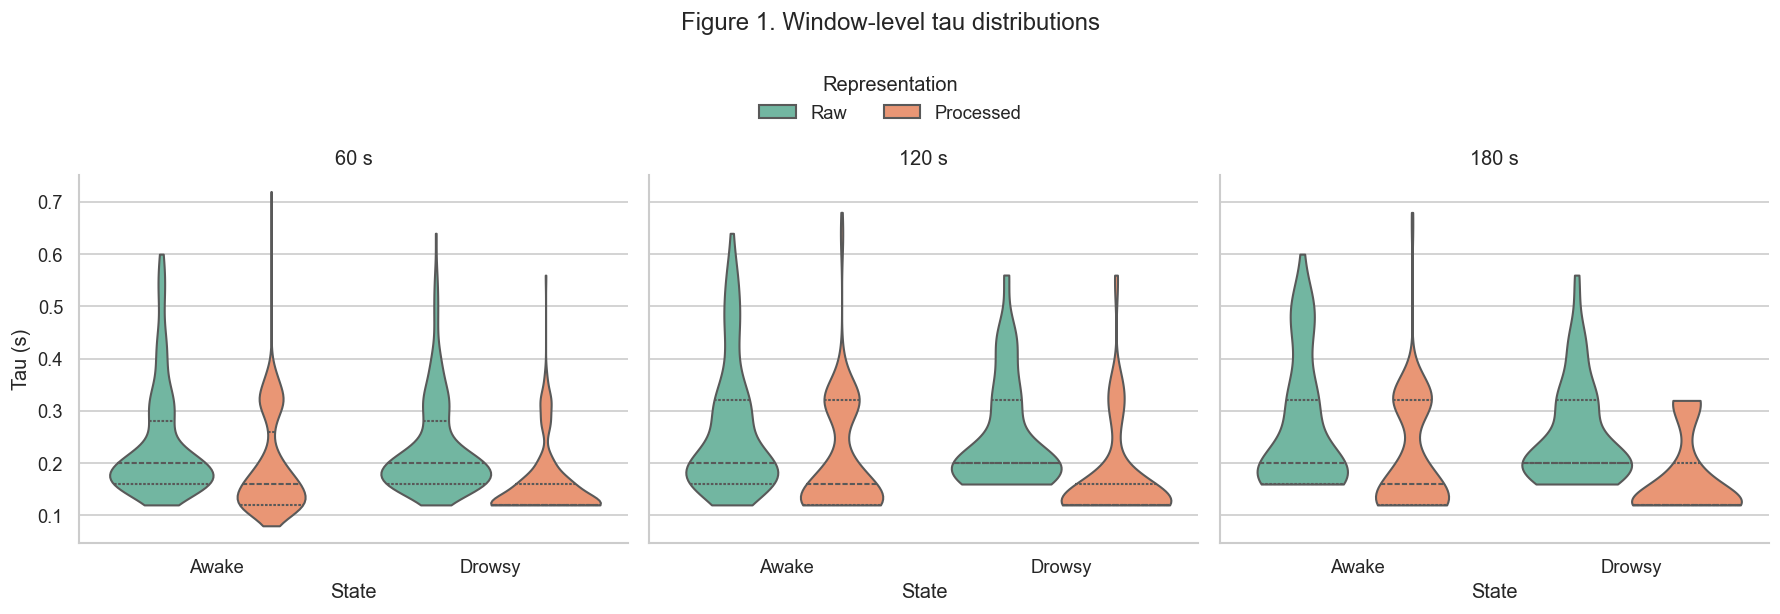

In [6]:
figure_1, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    sharey=True,
)
for axis, window_size in zip(axes, WINDOW_SIZES):
    subset = found_window[
        found_window["window_size_s"] == window_size
    ]
    sns.violinplot(
        data=subset,
        x="label",
        y="tau_seconds",
        hue="representation",
        cut=0,
        inner="quart",
        palette="Set2",
        ax=axis,
    )
    axis.set_title(f"{window_size} s")
    axis.set_xlabel("State")
    axis.set_ylabel("Tau (s)" if window_size == 60 else "")
    axis.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
figure_1.legend(
    handles,
    labels,
    title="Representation",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=2,
    frameon=False,
)
figure_1.suptitle(
    "Figure 1. Window-level tau distributions",
    y=1.02,
)
figure_1.tight_layout(rect=(0.0, 0.0, 1.0, 0.90))
figure_1.savefig(
    ANALYSIS_DIR / "figure_1_tau_distribution.png",
    bbox_inches="tight",
)
plt.show()

## 3. Within-session variability

`iqr_tau_seconds` mô tả variability giữa các window thuộc cùng một
session-level group.

In [7]:
within_size_summary = (
    analysis_session
    .groupby(
        ["window_size_s", "label", "representation"],
        observed=True,
    )["iqr_tau_seconds"]
    .agg(
        n_session_groups="size",
        median_iqr_seconds="median",
        q1_iqr_seconds=lambda values: values.quantile(0.25),
        q3_iqr_seconds=lambda values: values.quantile(0.75),
        max_iqr_seconds="max",
    )
    .reset_index()
)

session_variability = (
    analysis_session
    .groupby("session", observed=True)
    .agg(
        n_groups=("iqr_tau_seconds", "size"),
        total_windows=("n_windows", "sum"),
        median_iqr_seconds=("iqr_tau_seconds", "median"),
        max_iqr_seconds=("iqr_tau_seconds", "max"),
        min_median_tau_seconds=("median_tau_seconds", "min"),
        max_median_tau_seconds=("median_tau_seconds", "max"),
    )
    .reset_index()
)
session_variability["median_tau_range_seconds"] = (
    session_variability["max_median_tau_seconds"]
    - session_variability["min_median_tau_seconds"]
)
session_variability = session_variability.sort_values(
    ["max_iqr_seconds", "median_iqr_seconds"],
    ascending=False,
)

display(within_size_summary)
display(session_variability.head(10))

,window_size_s,label,representation,n_session_groups,median_iqr_seconds,q1_iqr_seconds,q3_iqr_seconds,max_iqr_seconds
0,60,Awake,Processed,20,0.070009,0.040006,0.159987,0.200065
1,60,Awake,Raw,20,0.050008,0.040006,0.105000,0.320032
2,60,Drowsy,Processed,20,0.040003,0.000000,0.070018,0.139986
3,60,Drowsy,Raw,20,0.040012,0.027506,0.100001,0.199980
4,120,Awake,Processed,20,0.040010,0.007501,0.135023,0.160052
5,120,Awake,Raw,20,0.040014,0.035000,0.115011,0.280091
6,120,Drowsy,Processed,20,0.000000,0.000000,0.082513,0.199997
7,120,Drowsy,Raw,19,0.099990,0.040014,0.130029,0.250025
8,180,Awake,Processed,20,0.040004,0.000000,0.090008,0.159984
9,180,Awake,Raw,20,0.050014,0.015000,0.080016,0.279972


,session,n_groups,total_windows,median_iqr_seconds,max_iqr_seconds,min_median_tau_seconds,max_median_tau_seconds,median_tau_range_seconds
12,sample_23.csv,12,184,0.080008,0.320032,0.160016,0.520052,0.360036
14,sample_4.csv,12,158,0.075024,0.280091,0.120039,0.200065,0.080026
15,sample_5.csv,12,138,0.159984,0.279972,0.199980,0.459954,0.259974
4,sample_13.csv,12,162,0.119998,0.259996,0.159998,0.479993,0.319995
7,sample_17.csv,12,147,0.120034,0.230066,0.160046,0.460131,0.300086
2,sample_11.csv,12,129,0.090022,0.200050,0.200050,0.320080,0.120030
10,sample_21.csv,12,136,0.025000,0.200000,0.120000,0.220000,0.100000
19,sample_9.csv,12,199,0.074998,0.189995,0.159996,0.359991,0.199995
9,sample_19.csv,12,149,0.040006,0.180027,0.120018,0.320048,0.200030
0,sample_1.csv,10,80,0.072500,0.165000,0.190000,0.420000,0.230000


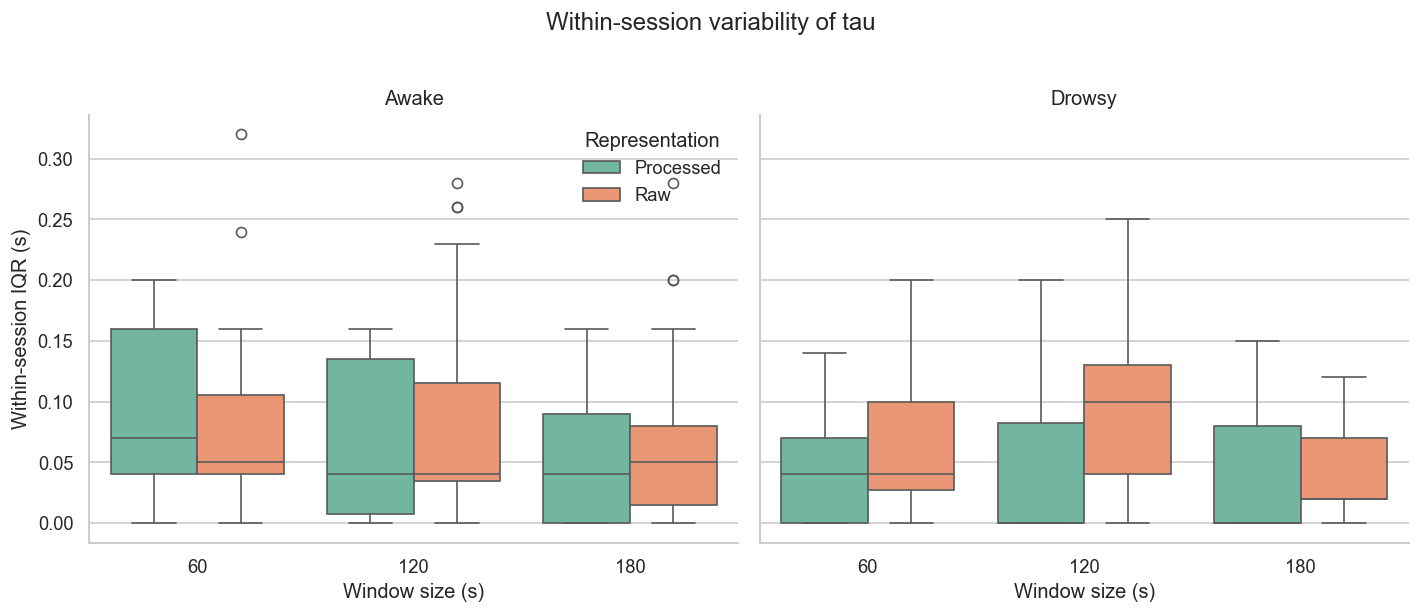

In [8]:
figure_within, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    sharey=True,
)
for axis, label in zip(axes, ("Awake", "Drowsy")):
    subset = analysis_session[analysis_session["label"] == label]
    sns.boxplot(
        data=subset,
        x="window_size_s",
        y="iqr_tau_seconds",
        hue="representation",
        palette="Set2",
        ax=axis,
    )
    axis.set_title(label)
    axis.set_xlabel("Window size (s)")
    axis.set_ylabel("Within-session IQR (s)" if label == "Awake" else "")
    if label == "Drowsy":
        axis.get_legend().remove()
    else:
        axis.legend(title="Representation", frameon=False)

figure_within.suptitle(
    "Within-session variability of tau",
    y=1.02,
)
figure_within.tight_layout()
figure_within.savefig(
    ANALYSIS_DIR / "within_session_variability.png",
    bbox_inches="tight",
)
plt.show()

Cửa sổ (s),Trạng thái,Representation,N,Trung vị tau (s),Trung vị |delta| (s),IQR |delta| (s),P90 |delta| (s),P95 |delta| (s),Trong 1 sample (%),Trong 2 samples (%)
60,Awake,Processed,596,0.160,0.080,0.040,0.120,0.160,30.0,67.3
60,Awake,Raw,550,0.200,0.040,0.080,0.200,0.280,58.5,70.9
60,Drowsy,Processed,305,0.120,0.080,0.040,0.080,0.120,23.0,77.0
60,Drowsy,Raw,267,0.200,0.040,0.080,0.160,0.200,60.3,74.5
120,Awake,Processed,269,0.160,0.080,0.080,0.120,0.160,24.9,60.6
120,Awake,Raw,245,0.200,0.040,0.120,0.280,0.320,51.0,58.8
120,Drowsy,Processed,136,0.120,0.080,0.025,0.120,0.160,19.9,69.1
120,Drowsy,Raw,118,0.200,0.040,0.120,0.240,0.240,60.2,67.8
180,Awake,Processed,161,0.160,0.080,0.080,0.120,0.160,23.6,57.8
180,Awake,Raw,147,0.200,0.040,0.120,0.280,0.320,51.7,59.2


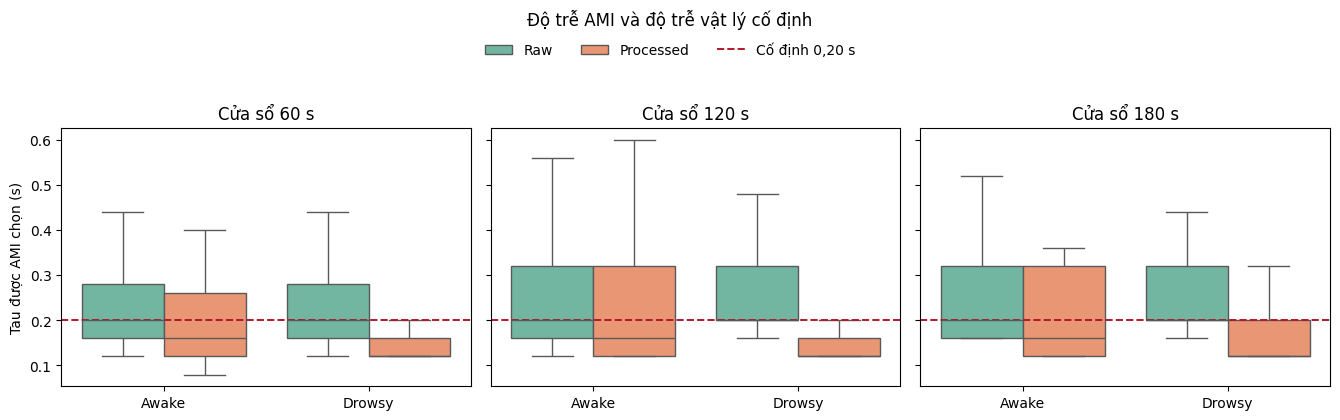


### Phản biện: sử dụng độ trễ vật lý cố định 0,20 giây

**Luận điểm.** `0,20 giây` là cấu hình chuẩn hóa được xác định trước cho các
phân tích NTSA tiếp theo. Dữ liệu AMI hỗ trợ trực tiếp giá trị này ở Raw, trong
khi mục đích sử dụng chung là giữ cùng thang thời gian và cấu hình nhúng giữa
Awake và Drowsy. Đây là sự đánh đổi có chủ đích giữa tối ưu theo từng cửa sổ và
khả năng so sánh, không phải tuyên bố rằng `0,20 giây` là cực tiểu AMI của mọi
cửa sổ hoặc mọi dạng dữ liệu.

**Bằng chứng hiện có.** Trên các cửa sổ 60/120/180 giây, trung vị tau của từng
nhóm là `0.200–0.200`
giây đối với Raw và
`0.120–0.160`
giây đối với Processed. Trung vị chênh lệch Awake–Drowsy ghép cặp ở cấp phiên
nằm trong
`0.000–0.000 giây`.
Chênh lệch Processed trừ Raw có trung vị
`-0.040` giây trên `1367`
cặp cửa sổ. Trung vị IQR nội phiên nằm trong
`0.000–0.100 giây`.
Trung vị chênh lệch tuyệt đối giữa các bảng tổng hợp 60/120/180 giây nằm trong
`0.000–0.000 giây`, với IQR từ
`0.020` đến `0.040 giây`.
Tỷ số biên tìm kiếm lớn nhất là `0.720`; có
`0/2942` cửa sổ đạt hoặc
vượt `0,80`. Phân tích độ nhạy cho thấy: k, đồng thuận với k=3: 68.07–77.73%; trung vị |delta|=0.0000 giây; max_lag, 0.5 giây: tìm thấy 96.22%, đồng thuận 100.00%, 1.0 giây: tìm thấy 100.00%, đồng thuận 100.00%, 1.5 giây: tìm thấy 100.00%, đồng thuận 100.00%.

**Mức độ phù hợp với 0,20 giây.** Trên toàn bộ `2942` cửa sổ hợp
lệ, trung vị sai lệch tuyệt đối là `0.080 giây`
(IQR `0.040 giây`; P90
`0.160 giây`; P95
`0.240 giây`). Raw gần 0,20 giây hơn
Processed: trung vị sai lệch tuyệt đối lần lượt là
`0.040` giây và
`0.080`
giây. Tỷ lệ nằm trong phạm vi một mẫu là
`56.8%` và
`25.6%`; trong
phạm vi hai mẫu là
`67.8%` và
`67.2%`.

**Triển khai theo thời gian vật lý.** Quy đổi chính xác là
`25 Hz → tau = 5 mẫu` và `50 Hz → tau = 10 mẫu`. Cần quy đổi theo tần số lấy
mẫu vì sử dụng cùng một độ trễ theo mẫu cho mọi phiên sẽ tạo ra các độ trễ vật
lý khác nhau. Ngược lại, `0,20 giây` giữ cùng thang thời gian động lực học giữa
các tần số lấy mẫu.

**Kết luận.** Dữ liệu thực nghiệm hỗ trợ `0,20 giây` như một độ trễ vật lý cố
định hợp lý, đặc biệt bởi trung tâm phân phối Raw trùng với giá trị này, kết quả
ổn định giữa 60/120/180 giây và không bị giới hạn bởi biên tìm kiếm. Processed
có tau AMI ngắn hơn, vì vậy `0,20 giây` không được mô tả là giá trị tối ưu theo
AMI cho mọi dạng dữ liệu. Giá trị cố định được dùng để Awake và Drowsy được
phân tích dưới cùng cấu hình nhúng; tau AMI theo từng cửa sổ vẫn được giữ làm
kết quả độ nhạy và tham chiếu.


In [2]:
FIXED_DELAY_SECONDS = 0.20


def iqr(values):
    """Return the interquartile range."""
    return values.quantile(0.75) - values.quantile(0.25)


fixed_data = analysis_window.loc[analysis_window["tau_found"]].copy()
fixed_data["fixed_tau_samples_ideal"] = (
    FIXED_DELAY_SECONDS * fixed_data["fs"]
)
fixed_data["abs_difference_seconds"] = (
    fixed_data["tau_seconds"] - FIXED_DELAY_SECONDS
).abs()
fixed_data["abs_difference_samples"] = (
    fixed_data["tau_samples"]
    - fixed_data["fixed_tau_samples_ideal"]
).abs()

fixed_delay_summary = (
    fixed_data
    .groupby(GROUP_KEYS, observed=True)
    .agg(
        n_windows=("tau_seconds", "size"),
        median_tau_seconds=("tau_seconds", "median"),
        median_abs_difference_seconds=(
            "abs_difference_seconds",
            "median",
        ),
        iqr_abs_difference_seconds=("abs_difference_seconds", iqr),
        p90_abs_difference_seconds=(
            "abs_difference_seconds",
            lambda values: values.quantile(0.90),
        ),
        p95_abs_difference_seconds=(
            "abs_difference_seconds",
            lambda values: values.quantile(0.95),
        ),
        within_1_sample_pct=(
            "abs_difference_samples",
            lambda values: 100.0 * (values <= 1).mean(),
        ),
        within_2_samples_pct=(
            "abs_difference_samples",
            lambda values: 100.0 * (values <= 2).mean(),
        ),
    )
    .reset_index()
)

representation_fit = (
    fixed_data
    .groupby("representation", observed=True)
    .agg(
        n_windows=("tau_seconds", "size"),
        median_abs_difference_seconds=(
            "abs_difference_seconds",
            "median",
        ),
        within_1_sample_pct=(
            "abs_difference_samples",
            lambda values: 100.0 * (values <= 1).mean(),
        ),
        within_2_samples_pct=(
            "abs_difference_samples",
            lambda values: 100.0 * (values <= 2).mean(),
        ),
    )
)

overall_difference = fixed_data["abs_difference_seconds"]
overall_iqr = iqr(overall_difference)

group_tau = (
    fixed_data
    .groupby(GROUP_KEYS, observed=True)["tau_seconds"]
    .median()
    .reset_index()
)
tau_ranges = group_tau.groupby("representation")["tau_seconds"].agg(
    ["min", "max"]
)

state_paired = (
    analysis_session
    .pivot_table(
        index=["session", "window_size_s", "representation"],
        columns="label",
        values="median_tau_seconds",
    )
    .dropna(subset=["Awake", "Drowsy"])
)
state_delta = state_paired["Drowsy"] - state_paired["Awake"]
state_delta_medians = state_delta.groupby(
    ["window_size_s", "representation"]
).median()

pair_keys = ["session", "window_size_s", "window_id", "label"]
raw_tau = fixed_data[fixed_data["representation"] == "Raw"]
processed_tau = fixed_data[fixed_data["representation"] == "Processed"]
matched_representation = raw_tau.merge(
    processed_tau,
    on=pair_keys,
    suffixes=("_raw", "_processed"),
    validate="one_to_one",
)
representation_delta = (
    matched_representation["tau_seconds_processed"]
    - matched_representation["tau_seconds_raw"]
)

within_group_iqr = (
    analysis_session
    .groupby(GROUP_KEYS, observed=True)["iqr_tau_seconds"]
    .median()
)

size_wide = analysis_session.pivot_table(
    index=["session", "label", "representation"],
    columns="window_size_s",
    values="median_tau_seconds",
)
size_differences = []
size_difference_iqrs = []
for first_size, second_size in ((60, 120), (60, 180), (120, 180)):
    difference = (
        size_wide[first_size] - size_wide[second_size]
    ).dropna().abs()
    size_differences.append(difference.median())
    size_difference_iqrs.append(iqr(difference))

boundary_ratio = (
    fixed_data["tau_samples"] / fixed_data["max_lag_samples"]
)

k_text = "không có trong kernel hiện tại"
if "k_sensitivity_summary" in globals():
    k_other = k_sensitivity_summary[
        k_sensitivity_summary["k"] != K_MAIN
    ]
    k_text = (
        f"đồng thuận với k={K_MAIN}: "
        f"{k_other['agreement_with_k3_pct'].min():.2f}–"
        f"{k_other['agreement_with_k3_pct'].max():.2f}%; "
        f"trung vị |delta|="
        f"{k_other['median_abs_delta_seconds'].max():.4f} giây"
    )

lag_text = "không có trong kernel hiện tại"
if "lag_sensitivity_summary" in globals():
    lag_text = ", ".join(
        f"{row.max_lag_seconds:.1f} giây: "
        f"tìm thấy {row.tau_found_rate_pct:.2f}%, "
        f"đồng thuận {row.agreement_with_main_pct:.2f}%"
        for row in lag_sensitivity_summary.itertuples()
    )

fixed_delay_summary.to_csv(
    ANALYSIS_DIR / "table_fixed_delay_020s.csv",
    index=False,
)

display_table = fixed_delay_summary.rename(columns={
    "window_size_s": "Cửa sổ (s)",
    "label": "Trạng thái",
    "representation": "Representation",
    "n_windows": "N",
    "median_tau_seconds": "Trung vị tau (s)",
    "median_abs_difference_seconds": "Trung vị |delta| (s)",
    "iqr_abs_difference_seconds": "IQR |delta| (s)",
    "p90_abs_difference_seconds": "P90 |delta| (s)",
    "p95_abs_difference_seconds": "P95 |delta| (s)",
    "within_1_sample_pct": "Trong 1 sample (%)",
    "within_2_samples_pct": "Trong 2 samples (%)",
})
display(
    display_table.style
    .format({
        "Trung vị tau (s)": "{:.3f}",
        "Trung vị |delta| (s)": "{:.3f}",
        "IQR |delta| (s)": "{:.3f}",
        "P90 |delta| (s)": "{:.3f}",
        "P95 |delta| (s)": "{:.3f}",
        "Trong 1 sample (%)": "{:.1f}",
        "Trong 2 samples (%)": "{:.1f}",
    })
    .hide(axis="index")
)

figure, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True)
for axis, window_size in zip(axes, WINDOW_SIZES):
    subset = fixed_data[fixed_data["window_size_s"] == window_size]
    sns.boxplot(
        data=subset,
        x="label",
        y="tau_seconds",
        hue="representation",
        showfliers=False,
        palette="Set2",
        ax=axis,
    )
    axis.axhline(
        FIXED_DELAY_SECONDS,
        color="#b2182b",
        linestyle="--",
        linewidth=1.4,
        label="Cố định 0,20 s",
    )
    axis.set_title(f"Cửa sổ {window_size} s")
    axis.set_xlabel("")
    axis.set_ylabel("Tau được AMI chọn (s)" if window_size == 60 else "")
    if window_size != 60:
        axis.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
figure.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=3,
    frameon=False,
)
axes[0].get_legend().remove()
figure.suptitle("Độ trễ AMI và độ trễ vật lý cố định", y=0.99)
figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.88))
figure.savefig(
    ANALYSIS_DIR / "figure_fixed_delay_020s.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

report = f"""
### Phản biện: sử dụng độ trễ vật lý cố định 0,20 giây

**Luận điểm.** `0,20 giây` là cấu hình chuẩn hóa được xác định trước cho các
phân tích NTSA tiếp theo. Dữ liệu AMI hỗ trợ trực tiếp giá trị này ở Raw, trong
khi mục đích sử dụng chung là giữ cùng thang thời gian và cấu hình nhúng giữa
Awake và Drowsy. Đây là sự đánh đổi có chủ đích giữa tối ưu theo từng cửa sổ và
khả năng so sánh, không phải tuyên bố rằng `0,20 giây` là cực tiểu AMI của mọi
cửa sổ hoặc mọi dạng dữ liệu.

**Bằng chứng hiện có.** Trên các cửa sổ 60/120/180 giây, trung vị tau của từng
nhóm là `{tau_ranges.loc['Raw', 'min']:.3f}–{tau_ranges.loc['Raw', 'max']:.3f}`
giây đối với Raw và
`{tau_ranges.loc['Processed', 'min']:.3f}–{tau_ranges.loc['Processed', 'max']:.3f}`
giây đối với Processed. Trung vị chênh lệch Awake–Drowsy ghép cặp ở cấp phiên
nằm trong
`{state_delta_medians.min():.3f}–{state_delta_medians.max():.3f} giây`.
Chênh lệch Processed trừ Raw có trung vị
`{representation_delta.median():.3f}` giây trên `{len(representation_delta)}`
cặp cửa sổ. Trung vị IQR nội phiên nằm trong
`{within_group_iqr.min():.3f}–{within_group_iqr.max():.3f} giây`.
Trung vị chênh lệch tuyệt đối giữa các bảng tổng hợp 60/120/180 giây nằm trong
`{min(size_differences):.3f}–{max(size_differences):.3f} giây`, với IQR từ
`{min(size_difference_iqrs):.3f}` đến `{max(size_difference_iqrs):.3f} giây`.
Tỷ số biên tìm kiếm lớn nhất là `{boundary_ratio.max():.3f}`; có
`{int((boundary_ratio >= 0.80).sum())}/{len(boundary_ratio)}` cửa sổ đạt hoặc
vượt `0,80`. Phân tích độ nhạy cho thấy: k, {k_text}; max_lag, {lag_text}.

**Mức độ phù hợp với 0,20 giây.** Trên toàn bộ `{len(fixed_data)}` cửa sổ hợp
lệ, trung vị sai lệch tuyệt đối là `{overall_difference.median():.3f} giây`
(IQR `{overall_iqr:.3f} giây`; P90
`{overall_difference.quantile(0.90):.3f} giây`; P95
`{overall_difference.quantile(0.95):.3f} giây`). Raw gần 0,20 giây hơn
Processed: trung vị sai lệch tuyệt đối lần lượt là
`{representation_fit.loc['Raw', 'median_abs_difference_seconds']:.3f}` giây và
`{representation_fit.loc['Processed', 'median_abs_difference_seconds']:.3f}`
giây. Tỷ lệ nằm trong phạm vi một mẫu là
`{representation_fit.loc['Raw', 'within_1_sample_pct']:.1f}%` và
`{representation_fit.loc['Processed', 'within_1_sample_pct']:.1f}%`; trong
phạm vi hai mẫu là
`{representation_fit.loc['Raw', 'within_2_samples_pct']:.1f}%` và
`{representation_fit.loc['Processed', 'within_2_samples_pct']:.1f}%`.

**Triển khai theo thời gian vật lý.** Quy đổi chính xác là
`25 Hz → tau = 5 mẫu` và `50 Hz → tau = 10 mẫu`. Cần quy đổi theo tần số lấy
mẫu vì sử dụng cùng một độ trễ theo mẫu cho mọi phiên sẽ tạo ra các độ trễ vật
lý khác nhau. Ngược lại, `0,20 giây` giữ cùng thang thời gian động lực học giữa
các tần số lấy mẫu.

**Kết luận.** Dữ liệu thực nghiệm hỗ trợ `0,20 giây` như một độ trễ vật lý cố
định hợp lý, đặc biệt bởi trung tâm phân phối Raw trùng với giá trị này, kết quả
ổn định giữa 60/120/180 giây và không bị giới hạn bởi biên tìm kiếm. Processed
có tau AMI ngắn hơn, vì vậy `0,20 giây` không được mô tả là giá trị tối ưu theo
AMI cho mọi dạng dữ liệu. Giá trị cố định được dùng để Awake và Drowsy được
phân tích dưới cùng cấu hình nhúng; tau AMI theo từng cửa sổ vẫn được giữ làm
kết quả độ nhạy và tham chiếu.
"""
display(Markdown(report))





